# Optimización del sleeve de equity (prior Black-Litterman)

Usa el modelo de `pipeline.py` (idéntico al notebook 02) y optimiza con skfolio:

- **Universo**: sleeve de equity → pesos long-only que suman 100% del sleeve. Este sleeve
  vive dentro del 30% Equity de la asignación estratégica de la tab `cliente`.
- **Objetivos**: Max Sharpe (con la Rf del Excel como tasa libre) y Min Varianza.
- **Constraints**: cap por posición `MAX_PESO` (default 10%) solo en la variante MinVar;
  se muestra también el Max Sharpe con cap como referencia de concentración.
- **Métricas**: in-sample sobre el propio prior BL (retorno/vol anuales, Sharpe manual).
- **Escritura**: copia del Excel (`data/empresas_data_final_pesos.xlsx`) con la col. AU
  (`Peso en Cartera`) = pesos del **Max Sharpe sin cap** (elección definida).
  SKHY y AUGO → 0 (excluidos).

> Convención de skfolio: `risk_free_rate` se expresa en la **frecuencia de X (diaria)** —
> verificado empíricamente. Las métricas del resumen se calculan a mano en términos anuales.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from openpyxl import load_workbook
from openpyxl.utils import get_column_letter
from skfolio.optimization import MeanRisk, ObjectiveFunction

from bl import PriorBlackLitterman
from pipeline import construir_modelo

pd.set_option("display.float_format", "{:.4f}".format)

# ---- Configuración ----
MAX_PESO = 0.10     # cap por posición dentro del sleeve de equity
ANNUAL = 252

modelo = construir_modelo()
orden = modelo.orden
rf_anual = modelo.params["risk_free"]
rf_diaria = rf_anual / ANNUAL

print(f"Universo efectivo: {len(orden)} empresas | excluidos: {modelo.excluidos}")
print(f"Nivel de equilibrio CAPM del universo (w'π): {float(modelo.mu_prior @ modelo.w_caps):.4%} anual")
print(f"Spread del posterior (rank 1 − último): {modelo.mu_post.iloc[0] - modelo.mu_post.iloc[-1]:.4%} anual")

Universo efectivo: 47 empresas | excluidos: ['SKHY', 'AUGO']
Nivel de equilibrio CAPM del universo (w'π): 11.1491% anual
Spread del posterior (rank 1 − último): 7.9996% anual


In [2]:
# ---- Optimizaciones ----
prior = PriorBlackLitterman(mu=modelo.mu_post_diario.values, covariance=modelo.sigma_bl)

w_ms_free = MeanRisk(
    objective_function=ObjectiveFunction.MAXIMIZE_RATIO,
    risk_free_rate=rf_diaria,
    max_weights=1.0,
    prior_estimator=prior,
).fit(modelo.X)
w_ms_free = pd.Series(w_ms_free.weights_, index=orden, name="MaxSharpe sin cap")

w_ms_cap = MeanRisk(
    objective_function=ObjectiveFunction.MAXIMIZE_RATIO,
    risk_free_rate=rf_diaria,
    max_weights=MAX_PESO,
    prior_estimator=prior,
).fit(modelo.X)
w_ms_cap = pd.Series(w_ms_cap.weights_, index=orden, name=f"MaxSharpe cap {MAX_PESO:.0%}")

w_mv_cap = MeanRisk(
    objective_function=ObjectiveFunction.MINIMIZE_RISK,
    max_weights=MAX_PESO,
    prior_estimator=prior,
).fit(modelo.X)
w_mv_cap = pd.Series(w_mv_cap.weights_, index=orden, name=f"MinVar cap {MAX_PESO:.0%}")

print("Optimizaciones completadas")

Optimizaciones completadas


In [3]:
# ---- Métricas in-sample sobre el prior BL ----
def metricas(w: pd.Series) -> dict:
    ret = float(w @ modelo.mu_post)
    vol = float(np.sqrt(w @ (modelo.sigma_bl @ w)) * np.sqrt(ANNUAL))
    return {
        "Retorno BL": ret,
        "Vol BL": vol,
        "Sharpe (Rf del Excel)": (ret - rf_anual) / vol,
        "Posiciones (>0.5%)": int((w > 0.005).sum()),
        "Suma top 5": float(w.nlargest(5).sum()),
    }

resumen = pd.DataFrame({w.name: metricas(w) for w in [w_ms_free, w_ms_cap, w_mv_cap]})
resumen

,MaxSharpe sin cap,MaxSharpe cap 10%,MinVar cap 10%
Retorno BL,0.1151,0.1164,0.1015
Vol BL,0.1783,0.1849,0.1687
Sharpe (Rf del Excel),0.3860,0.3793,0.3273
Posiciones (>0.5%),15.0000,16.0000,17.0000
Suma top 5,0.6580,0.5000,0.4997


In [4]:
# ---- Pesos por posición de ranking ----
tabla = pd.DataFrame(
    {
        "Ranking": range(1, len(orden) + 1),
        "Ticker": orden,
        "mu_post": modelo.mu_post.values,
        "w_ms_free": w_ms_free.values,
        "w_ms_cap": w_ms_cap.values,
        "w_mv_cap": w_mv_cap.values,
    }
)
tabla.head(15)

,Ranking,Ticker,mu_post,w_ms_free,w_ms_cap,w_mv_cap
0,1,RDDT,0.1386,0.0000,0.0000,0.0000
1,2,RELY,0.1369,0.0797,0.0980,0.0374
2,3,NU,0.1352,0.0333,0.0572,0.0000
3,4,SEZL,0.1334,0.0000,0.0000,0.0000
4,5,NVDA,0.1317,0.0489,0.0620,0.0012
5,6,TOST,0.1299,0.0178,0.0357,0.0000
6,7,RSSS,0.1282,0.1220,0.1000,0.0997
7,8,SPOT,0.1265,0.0215,0.0526,0.0100
8,9,NFLX,0.1247,0.1681,0.1000,0.1000
9,10,PLTR,0.1230,0.0000,0.0000,0.0000


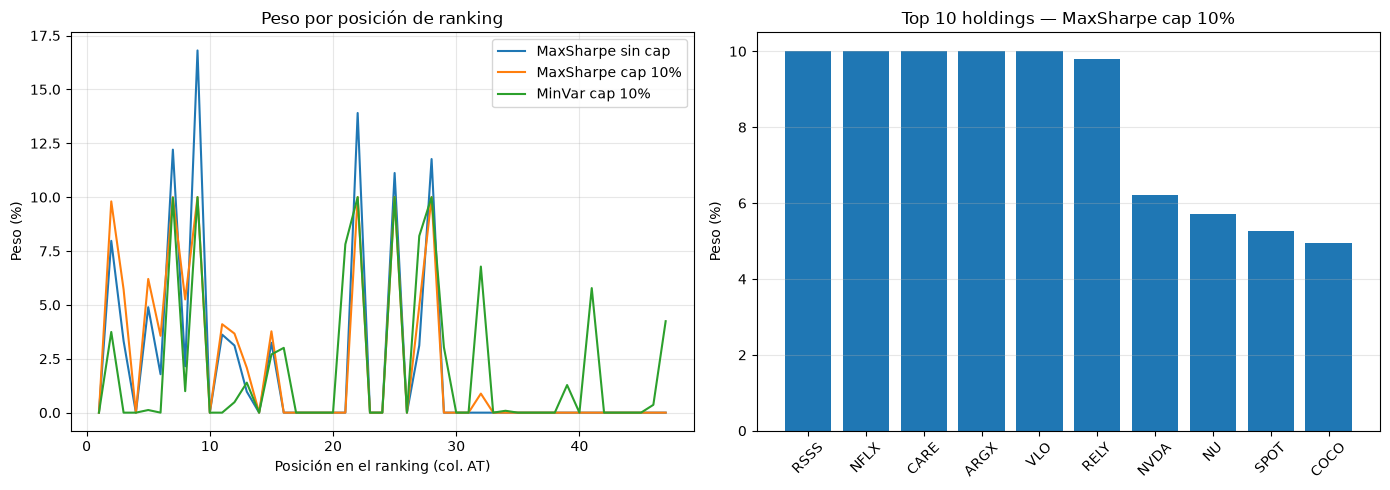

In [5]:
# ---- Gráficos: pesos por ranking y top holdings ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(1, len(orden) + 1)
axes[0].plot(x_pos, w_ms_free.values * 100, label="MaxSharpe sin cap", lw=1.5)
axes[0].plot(x_pos, w_ms_cap.values * 100, label=f"MaxSharpe cap {MAX_PESO:.0%}", lw=1.5)
axes[0].plot(x_pos, w_mv_cap.values * 100, label=f"MinVar cap {MAX_PESO:.0%}", lw=1.5)
axes[0].set_title("Peso por posición de ranking")
axes[0].set_xlabel("Posición en el ranking (col. AT)")
axes[0].set_ylabel("Peso (%)")
axes[0].legend()
axes[0].grid(alpha=0.3)

top = w_ms_cap.sort_values(ascending=False).head(10)
axes[1].bar(top.index, top.values * 100, color="tab:blue")
axes[1].set_title(f"Top 10 holdings — {w_ms_cap.name}")
axes[1].set_ylabel("Peso (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [6]:
# ---- Escritura de pesos: copia del Excel (col. AU) + CSV de variantes ----
from pathlib import Path

# Pesos escritos en AU: Max Sharpe sin cap (elección definida). SKHY y AUGO (excluidos) → 0.
pesos_au = w_ms_free.copy()
for t in modelo.excluidos:
    pesos_au[t] = 0.0

wb = load_workbook("../data/empresas_data_final.xlsx")
ws = wb["data"]
col_peso = 47  # AU
assert get_column_letter(col_peso) == "AU"

escritos = 0
for row in range(3, ws.max_row + 1):
    ticker = ws.cell(row=row, column=1).value
    if ticker is None:
        continue
    ticker = str(ticker).strip()
    if ticker in pesos_au.index:
        ws.cell(row=row, column=col_peso).value = float(pesos_au[ticker])
        escritos += 1

wb.save("../data/empresas_data_final_pesos.xlsx")
print(f"Col. AU escrita con Max Sharpe sin cap para {escritos} empresas → data/empresas_data_final_pesos.xlsx")

out = Path("../outputs")
out.mkdir(exist_ok=True)
salida = pd.DataFrame(
    {
        "Ranking": range(1, len(orden) + 1),
        "Ticker": orden,
        "MaxSharpeSinCap": w_ms_free.values,
        "MaxSharpeCap10": w_ms_cap.values,
        "MinVarCap10": w_mv_cap.values,
    }
)
salida.to_csv(out / "pesos_sleeve_equity.csv", index=False)
print(f"CSV de variantes → {out / 'pesos_sleeve_equity.csv'}")
salida.describe().loc[["min", "max", "mean"]]

Col. AU escrita con Max Sharpe sin cap para 49 empresas → data/empresas_data_final_pesos.xlsx
CSV de variantes → ../outputs/pesos_sleeve_equity.csv


,Ranking,MaxSharpeSinCap,MaxSharpeCap10,MinVarCap10
min,1.0000,0.0000,0.0000,0.0000
max,47.0000,0.1681,0.1000,0.1000
mean,24.0000,0.0213,0.0213,0.0213


## Conclusiones

- **Max Sharpe sin cap**: cartera **escrita en la col. AU** (elección definida). Sin límite
  de concentración: 15 posiciones y top 5 = 65.8% (NFLX 16.8%, RSSS 12.2%).
- **Min Varianza (cap 10%)**: variante comparativa; ignora el μ del prior (usa solo Σ_BL)
  → pesos más planos, dominados por el control de riesgo.
- **Max Sharpe cap 10%**: variante intermedia si se quiere limitar concentración (top 5 = 50%).
- La col. AU de la copia del Excel contiene los pesos del sleeve (suman 100%). La
  contribución al portafolio total sería peso × 30% (Equity de la SAA del cliente).
- Métricas in-sample sobre el propio prior BL — no constituyen backtest.

**Próximos pasos posibles**:
1. Backtest out-of-sample (walk-forward re-optimizando por período).
2. Constraints por sector/industria si el cliente define bandas a ese nivel.
3. Escala de AU: pesos del sleeve (actual) vs contribución al portafolio total (×30%).